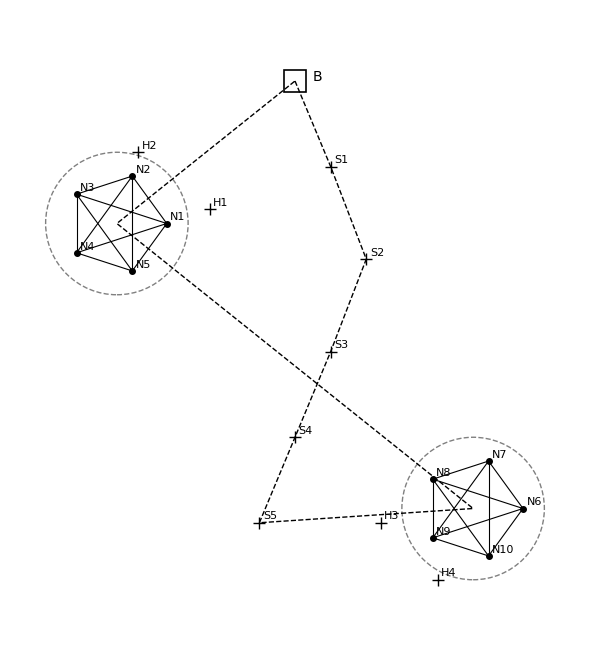

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# -----------------------------------------------------------
# Helpers
# -----------------------------------------------------------

def draw_cluster(ax, center, radius=0.6, n_nodes=5, name_prefix="N", start_index=1):
    """
    Desenha um pequeno grafo de comunicação (cluster de sensores)
    em torno de 'center' com 'n_nodes' nós.
    """
    cx, cy = center
    nodes = []

    # distribui nós em círculo
    import numpy as np
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    for k, ang in enumerate(angles):
        x = cx + radius * 0.7 * np.cos(ang)
        y = cy + radius * 0.7 * np.sin(ang)
        nodes.append((x, y))

    # desenha conexões (aqui faço um grafo denso, tipo "tudo com tudo")
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            x1, y1 = nodes[i]
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], color="black", linewidth=0.8)

    # desenha nós
    for idx, (x, y) in enumerate(nodes, start=start_index):
        ax.plot(x, y, "ko", markersize=4)
        ax.text(x+0.05, y+0.05, f"{name_prefix}{idx}", fontsize=8)

    # contorno tracejado do cluster (região de comunicação)
    circle = Circle(center, radius, edgecolor="gray", linestyle="--",
                    facecolor="none", linewidth=1.0)
    ax.add_patch(circle)


def draw_sojourn(ax, pos, label=None):
    """Desenha um sojourn local (posição candidata do sink)."""
    x, y = pos
    ax.plot(x, y, marker="+", markersize=8, color="black")
    if label:
        ax.text(x+0.05, y+0.05, label, fontsize=8)

# -----------------------------------------------------------
# Montagem da figura
# -----------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 8))

# Base (B)
base = (0, 4)
ax.add_patch(Rectangle((base[0]-0.15, base[1]-0.15), 0.3, 0.3,
                       fill=False, edgecolor="black", linewidth=1.2))
ax.text(base[0]+0.25, base[1], "B", fontsize=10)

# Sojourns ao longo da trajetória (somente exemplo)
sojourns = [
    (0.5, 2.8),
    (1.0, 1.5),
    (0.5, 0.2),
    (0.0, -1.0),
    (-0.5, -2.2),
]

# clusters de sensores (parte superior e inferior da figura)
cluster_top_center = (-2.5, 2.0)
cluster_bot_center = (2.5, -2.0)

# desenha clusters de comunicação
draw_cluster(ax, cluster_top_center, radius=1.0, n_nodes=5,
             name_prefix="N", start_index=1)
draw_cluster(ax, cluster_bot_center, radius=1.0, n_nodes=5,
             name_prefix="N", start_index=6)

# sojourns locais próximos aos clusters (regiões de parada do sink)
local_sojourns_top = [(-1.2, 2.2), (-2.2, 3.0)]
local_sojourns_bot = [(1.2, -2.2), (2.0, -3.0)]

for i, p in enumerate(local_sojourns_top, start=1):
    draw_sojourn(ax, p, label=f"H{i}")

for i, p in enumerate(local_sojourns_bot, start=3):
    draw_sojourn(ax, p, label=f"H{i}")

# desenha sojourns ao longo do caminho global
for i, p in enumerate(sojourns, start=1):
    draw_sojourn(ax, p, label=f"S{i}")

# -----------------------------------------------------------
# Trajetória do sink (grafo de movimentos possíveis)
# -----------------------------------------------------------

# caminho principal: base -> sojourns -> de volta para base (apenas exemplo)
path_points = [base] + sojourns + [cluster_bot_center, cluster_top_center, base]

x_path = [p[0] for p in path_points]
y_path = [p[1] for p in path_points]
ax.plot(x_path, y_path, linestyle="--", color="black", linewidth=1.0)

# -----------------------------------------------------------
# Ajustes visuais
# -----------------------------------------------------------

ax.set_aspect("equal", "box")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 5)
ax.axis("off")

plt.tight_layout()
plt.show()
